In [ ]:
# markdown cheatsheet - https://github.com/adam-p/markdown-here/wiki/Markdown-Cheatsheet

## **Basic Neural Network Workflow (with PyTorch)**

![Neural Network Workflow](images/neural_network_workflow.png "Neural Network Workflow")

Things covered in the following tutorial

| Topic | Contents |
|----------|----------|
| **1. Getting data ready** | For this tutorial, we'll be modeling a simple **straight line** using a **neural network** (a type of machine learning **model**) |
| **2. Building a model** | We'll create a neural network, alongisde choosing a **loss function** and **optimizer** and creating a **training loop** |
| **3. Fitting the model to data (training)** | We'll run the neural network through the training loop to let it learn **patterns** in the **train** data |
| **4. Making predictions and evaluating a model (inference and testing)** | The neural network we made learned some patterns, so now we have to verify them using the **test** data |
| **5. Saving and loading a model** | We might want to use the model later, so let's save it |

Let's create a dictionary for all the steps we're covering in this tutorial

In [ ]:
steps_of_tutorial = {1: "getting data ready (prepare and load)",
    2: "building model",
    3: "fitting the model to data (training)",
    4: "making predictions and evaluating a model (inference and testing)",
    5: "saving and loading a model"
}

Now, let's import the libraries necessary to create our first neural network!

In [ ]:
import torch    # The full package for PyTorch, a common library for making very customizable neural networks
from torch import nn   # "nn" stands for neural network - this section of PyTorch contains the building blocks for neural networks
import matplotlib.pyplot as plt     # A library to help create graphs

# Check PyTorch version - "x.x.x" indicates the version of PyTorch, while "+cuXXX" shows the version of cuda 
# (a backend that helps run neural networks even faster on GPUs!) it is compatible with
torch.__version__

'2.3.1+cu121'

### **1. Getting data ready (preparing and loading)**

Machine learning needs you to:
1. Turn your data into numbers (a "numerical representation")
2. Pick or build a model to learn patterns about the representation as best as possible

Right now, we don't have any data. Instead we'll make some data - a straight line.

We'll create the data with known **parameters** (values that are learned by a model) and see if we can build a neural network from PyTorch to **estimate these same values** by finding patterns within the training data

In [4]:
# Create our "known" parameters
weight = 0.7
bias = 0.3

# Create data
start = 0
end = 1
step = 0.02
X = torch.arange(start, end, step).unsqueeze(dim=1)     # our "features"
y = weight * X + bias   # our "labels"

X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

Now, we're going to build a model that can learn the relationship between `X` (**features**) and `y` (**labels**)

#### Split data into train and test sets

We have some data for a straight line, but we need to split it up into a training and testing set (and sometimes a validation set).

| Split | Purpose | Proportion of total data | How often is it used? |
|----------|----------|----------|----------|
| **Train set** | The model learns from this data (like the notes you study from) | ~60-80% | Always |
| **Validation set** | The model shows its performance on this data while learning (like a practice test before the actual test) | ~10-20% | Often, but not always |
| **Testing set** | The model gets evaluated on this data to see what it's learned (like the actual test) | ~10-20% | Always |

We're only going to use a training and testing set for this example. We can create them by splitting the `X` and `y` values.

> Note: When using real-world data, this is one of the first steps to keep the test set separate from the other data. We want the model to learn from train data and see how it good it does on test data to learn how well it **generalizes** to examples its never seen before.

In [5]:
# Create train/test split
train_split = int(0.8 * len(X)) # 80% of data used for training set, 20% for testing 

# Often, this process can be done with a another Python library
# However, to keep things simple, we'll do it manually
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

Now we have 40 samples for training (`X_train` and `y_train`) alongside 10 samples for testing (`X_test` and `y_test`). The neural network we create will try to learn the relationship between `X_train` and `y_train`, and then we'll see what relationships were found by using `X_test` and `y_test`

Let's see how these values actually look with a graph

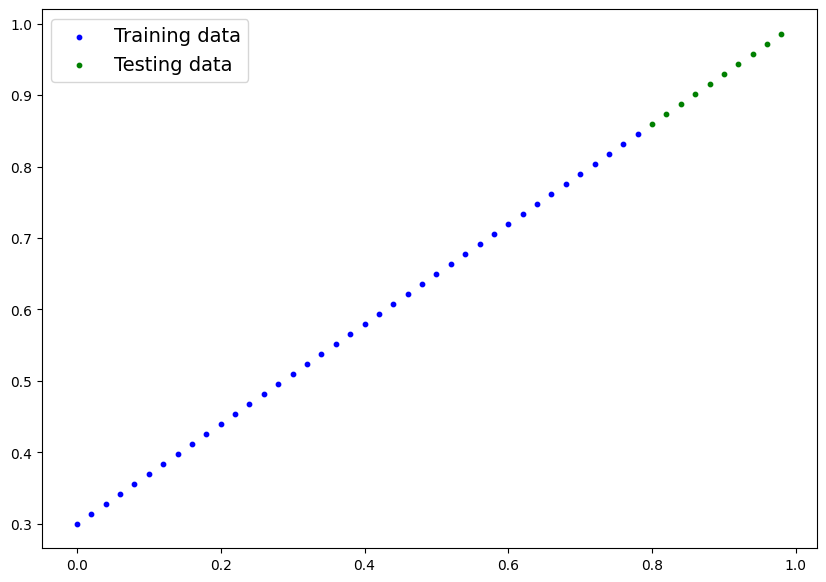

In [ ]:
def plot_predictions(train_data=X_train,
                     train_labels=y_train,
                     test_data=X_test,
                     test_labels=y_test,
                     predictions=None):
    """
    Plots training data, test data and compares predictions.
    """
    plt.figure(figsize=(10, 7))

    # Plot training data in blue
    plt.scatter(train_data, train_labels, c="b", s=10, label="Training data")
    
    # Plot test data in green
    plt.scatter(test_data, test_labels, c="g", s=10, label="Testing data")

    if predictions is not None:
        # Plot the predictions in red (predictions were made on the test data)
        plt.scatter(test_data, predictions, c="r", s=10, label="Predictions")

    # Show the legend
    plt.legend(prop={"size": 14})

# Note: visualizing is always a great way to look at and understand data
# It's also great for learning any concept in general
plot_predictions()

### **2. Build model**

We've made our straight line data. Now, let's make a neural network to learn patterns from the blue dots to predict the green dots.

PyTorch has (loosely) four modules that are needed to create any kind of neural network.

They are `torch.nn`, `torch.optim`, `torch.utils.data.Dataset` and `torch.utils.data.DataLoader`. For this tutorial, we will only talk about the first two.

| PyTorch module | What does it do? |
|----------|----------|
| `torch.nn` | Has all the building blocks for neural networks |
| `torch.nn.Parameter` | Stores values to be used in `nn.Module`. If `requires_grad=True`, then calculations for learning about training data are done automatically - this is often named "autograd". |
| `torch.nn.Module` | The base class for all neural networks. If you're building a neural network in PyTorch, your model should be built on top of (subclass) `nn.Module`, and the `forward()` method should be overwritten |
| `torch.optim` | Contains various methods to help the neural network learn. It takes the values in `nn.Parameter` and tells it how to best change to minimize the error between real values and values predicted by the neural network |
| `def forward` | All `nn.Module` subclasses require a `forward()` method. This defines the computation that will take place on the data passed to the `nn.Module` |

Everything in a PyTorch neural network comes from `torch.nn`.
- `nn.Module` has the larger building blocks (layers)
- `nn.Parameter` has the smaller building blocks (that can be put together to make a `nn.Module`)
- `forward()` tells the larger and smaller building blocks how to change the input data to more closely resemble the output
- `torch.optim` contains different ways for the neural network to improve the `nn.Parameter`s to better change the input data to resemble the output data

In [ ]:
# Creating a neural network to learn how to continue a straight line with the same parameters (weight/bias) we made it from
class LinearRegressionModel(nn.Module): # We just took all the information from "nn.Module" and put it in the class we're building
    # Almost everything in PyTorch is a nn.Module (the neural network "lego blocks")
    def __init__(self):
        super().__init__()
        self.weight = nn.Parameter(
            torch.randn(1,  # This starts with a random weight, but it gets adjusted as the model learns
                        dtype=torch.float), # Generic data type for PyTorch
            requires_grad=True  # Can we update this value as the model is learning? If this is "true", then we can update it
        )

        self.bias = nn.Parameter(
            torch.randn(1,  # This starts with a random weight, but it gets adjusted as the model learns
                        dtype=torch.float), # Generic data type for PyTorch
            requires_grad=True  # Can we update this value as the model is learning? If this is "true", then we can update it
        )

        # All of the contents can be replaced by a simple nn.Module named "nn.Linear"
        # Instead of defining two parameters one-by-one, you could use the following line to make the code more concise
        # This is always done when regularly coding neural networks
        # self.linear_layer = nn.Linear(in_features = 1, out_features = 1)

    # Forward 
    def forward(self, x):   # "x" is the input data 
        return self.weight * x + self.bias  # This is the same formula for a line (y = m * x + b)
        # This converts our input data into an output and compares that with data from the "true" line we made

        # If we use our `self.linear_layer`, we can just do the following:
        # return self.linear_layer(x)

#### Checking the contents of a PyTorch neural network model

Now that we've defined our model with a class, let's make a model and check its parameters using `.parameters()`

In [10]:
# Set manual seed for reproducible randomness since nn.Parameter(s) are randomly initialized
# ^ "s" is in parentheses next to nn.Parameter above since the function's true name does not have an "s"
torch.manual_seed(42)

# Create an instance of the simple model we made
model_0 = LinearRegressionModel()

# Check the nn.Parameter(s) within the nn.Module version we made
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

We can also get the state (the contents) of the model using `.state_dict()`

In [11]:
model_0.state_dict()

OrderedDict([('weight', tensor([0.3367])), ('bias', tensor([0.1288]))])

The values of `weight` and `bias` are random because we initialized them with a random function (`torch.randn()`)

We want to start from random parameters (weights/biases), and get the neural network to update them towards parameters that fit the data the best.

In this case, the best possible values for `weight` and `bias` are the hard-coded values we set earlier, 0.7 and 0.3, respectively.

Because our model starts with a random `weight` and `bias`, the current predictions are going to be completely off-target

#### Making predictions using `torch.inference_mode()`

To check how bad the current parameters are, we can pass it the test data, `X_test`, and compare it to the `y_test` values.

When we pass data to our model, it'll go through the model's `forward()` that we defined earlier and produced a result based on that computation

When doing model evaluation, we want to use `torch.inference_mode()` to turn off a bunch of things that are needed for training but unnecessary for testing. This makes evaluation faster altogether.

In [12]:
# Make predictions with the model
with torch.inference_mode():
    y_preds = model_0(X_test)

# Note: in older PyTorch code, you might also see torch.no_grad() for inference
# torch.inference_mode() and torch.no_grad() do similar things, but torch.inference_mode() is newer, possibly faster, and now preferred
# with torch.no_grad():
#     y_preds = model_0(X_test)

Now, let's see what the predictions look like

In [13]:
# Check the predictions
print(f"Number of testing samples: {len(X_test)}") 
print(f"Number of predictions made: {len(y_preds)}")
print(f"Predicted values:\n{y_preds}")

Number of testing samples: 10
Number of predictions made: 10
Predicted values:
tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])


There's only one prediction value per testing sample, since our data takes one `X` value and maps it to one `y` value. However, machine learning models are flexible, and can take any amount of `X` values and map to any amount of `y` values.

Let's visualize our predictions to see how bad they are

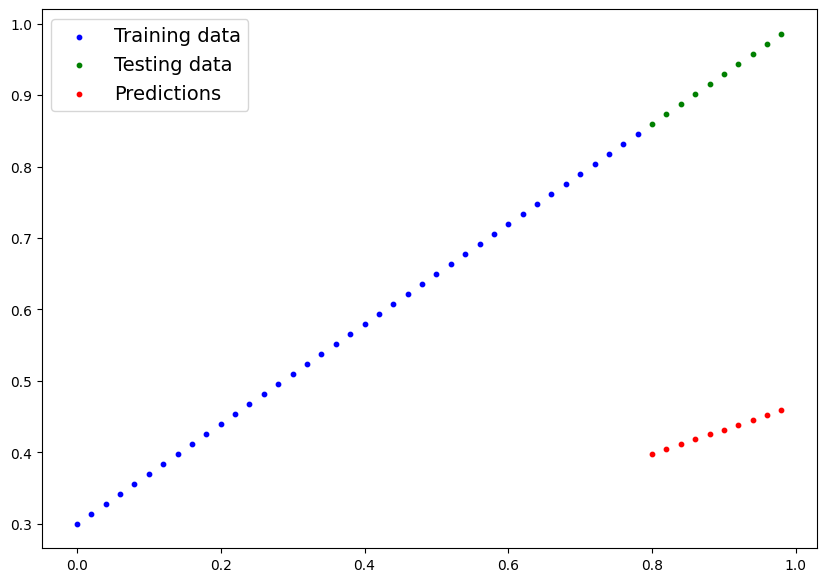

In [14]:
plot_predictions(predictions=y_preds)

In [15]:
y_test - y_preds    # Subtracting y_preds from y_test to see how far away they are

tensor([[0.4618],
        [0.4691],
        [0.4764],
        [0.4836],
        [0.4909],
        [0.4982],
        [0.5054],
        [0.5127],
        [0.5200],
        [0.5272]])

Like we thought, these predictions are pretty bad, since we're just using random parameter values to make predictions rather than training the neural network and then making predictions

### **3. Train model**

Right now, the model is basically guessing. We just used random parameters to make predictions on our test data rather than learning anything new beforehand.

To fix that, we can update the parameters (also colloquially referenced as their patterns), or the `weight` and `bias` values we set randomly with `nn.Parameter()` and `torch.randn()`, to be something that better represents the data

We could manually change the `weight` and `bias` values within our model to be 0.7 and 0.3. But, if we had hundreds of thousands of parameters, where we don't even know the ideal values, this would be impossible.
> Note: ChatGPT 3 (which is an older version - the current version is ChatGPT 5) has 175 billion parameters. Imagine changing all of those by hand!

#### Creating a loss function and optimizer in PyTorch

For our model to update its parameters, we need a few more things: a loss function, and an optimizer.

| Function | What does it do? | Where does it live in PyTorch? | Common values |
|----------|----------|----------|----------|
| **Loss function** | Measures how wrong your model's predictions (`y_pred`) are compared to the truth labels (`y_test`). Usually, the lower the better | PyTorch has many built-in loss functions in `torch.nn` | Mean absolute error (MAE) or mean squared error (MSE) for regression problems (`torch.nn.L1Loss()`, `torch.nn.MSELoss()`), and binary cross entropy for binary classification problems (`torch.nn.BCELoss`)|
| **Optimizer** | Tells your model how exactly to update its internal parameters to best lower the loss | PyTorch has many built in optimization algorithms implemented in `torch.optim` | Stochastic gradient descent (`torch.optim.SGD()`), or the Adam optimizer (`torch.optim.Adam()`) |